# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data set import and overview

In [2]:
df=pd.read_excel(r"Metromove_ Raw_Dataset.xlsx")

In [3]:
print(f'Data Set has: {df.shape[0]} rows x {df.shape[1]} columns')

Data Set has: 1000 rows x 12 columns


In [4]:
df.head(2)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F


In [5]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [6]:
df.describe(include="all")

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
count,1000,1000,1000,1000,1000,900.000000,900.000000,900.000000,1000,1000,0.0,299
unique,1000,9,7,7,NaN,NaN,NaN,NaN,NaN,7,NaN,2
top,TRIP0001,Bus,North Station,South Point,NaN,NaN,NaN,NaN,NaN,Sunday,NaN,F
freq,1,147,171,171,NaN,NaN,NaN,NaN,NaN,167,NaN,250
mean,NaN,NaN,NaN,NaN,2024-01-01 14:19:30,49.154444,25.360742,94.270000,2024-01-21 08:03:50.400000,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,2024-01-01 06:00:00,1.000000,0.500576,5.000000,2024-01-01 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,2024-01-01 10:09:45,25.000000,12.818196,49.750000,2024-01-11 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,2024-01-01 14:19:30,48.000000,25.403856,97.500000,2024-01-21 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,2024-01-01 18:29:15,72.000000,37.866623,138.000000,2024-02-01 00:00:00,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,2024-01-01 22:39:00,99.000000,49.945184,179.000000,2024-02-11 00:00:00,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 93.9+

# Data Preprocessing and Cleaning

In [8]:
# Confirm duplicated data

df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [9]:
# Confirm missing values

df.isnull().sum()

Trip_ID                     0
Mode_of_Transport           0
Departure_Station           0
Arrival_Station             0
Departure_Time              0
Passenger_Count           100
Fare_Amount               100
Trip_Duration_Minutes     100
Trip_Date                   0
Day_of_Week                 0
Unnamed: 10              1000
Unnamed: 11               701
dtype: int64

In [10]:
# Handle missing values

#Drop unnamed columns 10 & 11
df = df.drop(columns= ['Unnamed: 10', 'Unnamed: 11'])


In [11]:
# Confirm if missing values in other columns can be replaced with mean or median

df[["Passenger_Count", "Fare_Amount", "Trip_Duration_Minutes"]].agg(["min", "max", "median", "mean"])

,Passenger_Count,Fare_Amount,Trip_Duration_Minutes
min,1.000000,0.500576,5.00
max,99.000000,49.945184,179.00
median,48.000000,25.403856,97.50
mean,49.154444,25.360742,94.27


In [12]:
df["Passenger_Count"] =df["Passenger_Count"].fillna(0)
df["Fare_Amount"]=df["Fare_Amount"].fillna(df["Fare_Amount"].mean())
df["Trip_Duration_Minutes"]=df["Trip_Duration_Minutes"].fillna(df["Trip_Duration_Minutes"].mean())

In [13]:
# Creating month and time stamp features from the Departure Time and Trip Date feature

df['Departure_hour']= df['Departure_Time'].dt.hour
df['Trip_Month']= df['Trip_Date'].dt.month_name()
df['Trip_Day']= df['Trip_Date'].dt.day_name()

In [14]:
#crosschecking data

df.head(10)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Departure_hour,Trip_Month,Trip_Day
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.00,2024-01-01,Sunday,6,January,Monday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.00,2024-01-01,Saturday,6,January,Monday
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,25.360742,94.27,2024-01-01,Tuesday,6,January,Monday
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,94.27,2024-01-01,Sunday,6,January,Monday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.360742,94.27,2024-01-01,Monday,6,January,Monday
5,TRIP0006,fErry,South Point,South Point,2024-01-01 06:05:00,41.0,5.994406,50.00,2024-01-01,Thursday,6,January,Monday
6,TRIP0007,bus,West End,West End,2024-01-01 06:06:00,13.0,40.507643,100.00,2024-01-01,Saturday,6,January,Monday
7,TRIP0008,FERRY,Central,South Point,2024-01-01 06:07:00,9.0,25.360742,14.00,2024-01-01,Saturday,6,January,Monday
8,TRIP0009,Train,West End,North Station,2024-01-01 06:08:00,36.0,4.079666,172.00,2024-01-01,Saturday,6,January,Monday
9,TRIP0010,Ferry,Central,South Point,2024-01-01 06:09:00,86.0,47.778203,132.00,2024-01-01,Wednesday,6,January,Monday


In [15]:
# Addressing Discrepancy observed in Day_of_Week Column

df= df.drop(['Day_of_Week'], axis=1)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Departure_hour         1000 non-null   int32         
 10  Trip_Month             1000 non-null   object        
 11  Trip_Day               1000 non-null   object        
dtypes: datetime64[ns](2), float64(3), int32(1), object(6)
memory us

In [17]:
# Convert Passenger Count to int data type

df['Passenger_Count'] = df['Passenger_Count'].astype(int)


In [18]:
numeric_cols= (['Passenger_Count', 'Fare_Amount','Trip_Duration_Minutes', 'Departure_hour'])
    
categorical_cols= (['Mode_of_Transport', 'Departure_Station', 'Arrival_Station','Trip_Month','Trip_Day'])


In [19]:
# Standardize categorical variables: strip spaces + title case

for col in categorical_cols:
    df[col]= df[col].str.strip().str.title()

##### Data Cleaning Notes
An initial review of missing-value patterns showed that two columns (Unnamed: 10 and Unnamed: 11) contained extremely high proportions of null values and no meaningful information. These were removed entirely to prevent unnecessary noise in the dataset.

For the remaining columns with missing values, I examined distribution characteristics and compared mean–median differences to guide appropriate imputation strategies.
- Passenger_Count was imputed with 0, reflecting a valid real-world value rather than a statistical estimate.
- Due to minimal difference between mean and median for Fare_Amount and Trip_Duration_Minutes the mean was applied where all NA values were reported.

Categorical columns were standardized through whitespace trimming and consistent casing, and resolving missing values in numerical fields using appropriate imputation methods to ensure accuracy and analytical readiness.”

The original Day_of_Week column contained inconsistencies relative to the Trip_Date values. To ensure accuracy, the column was removed and regenerated programmatically from the Trip_Date field.”

Trip Month, Trip Day, Departure Time and Hour were added as new features. They were derived from the Trip Date and Departure Time

# Exploratory Data Analysis (EDA)

#### Univariate Analysis

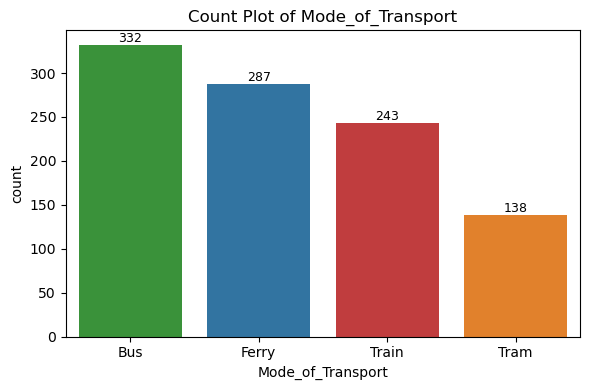

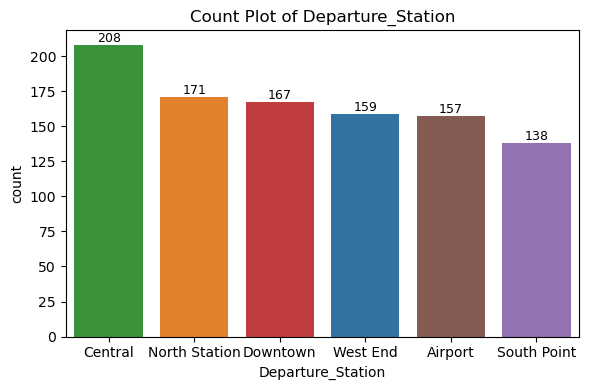

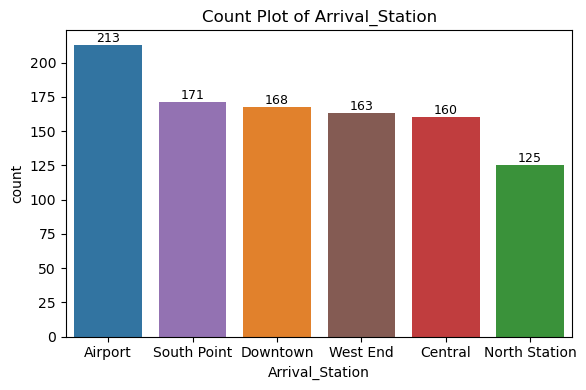

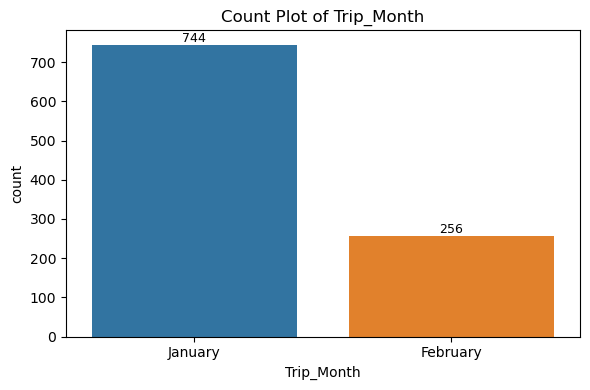

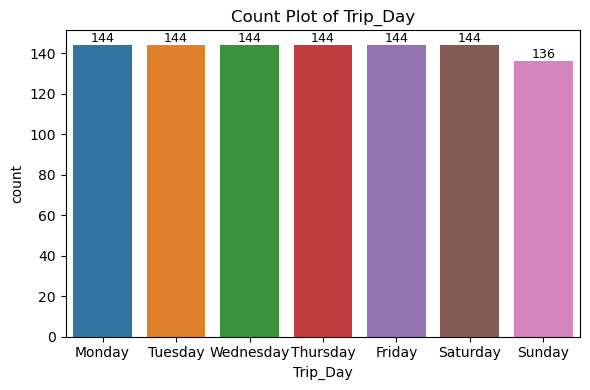

In [20]:
# EDA Categorical Variables

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    ax= sns.countplot(data=df, x=col, hue=col, order=df[col].value_counts().index)
    for container in ax.containers:
        ax.bar_label(container, fontsize=9)
    plt.title(f"Count Plot of {col}")
    plt.tight_layout()
    plt.show()


Text(0.5, 1.0, 'Trip distribution by Month')

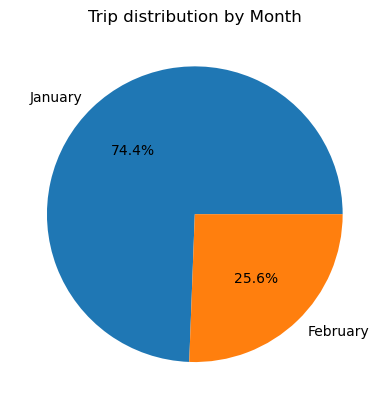

In [21]:
#Trip Distribution by Month(Pie Chart)

target_counts = df['Trip_Month'].value_counts()
target_counts
    
plt.pie(target_counts,labels= ['January', 'February'], autopct ='%1.1f%%' ) 
plt.title("Trip distribution by Month")

#### Insight:

Overall, the categorical variables show:

- **Bus** and **Central** dominate as the primary mode and departure hub.  
- **Airport** stands out as the most common arrival destination.  
- **January** has far more trips than February.  
- **Daily trip counts are stable**, with only a small dip on Sundays.


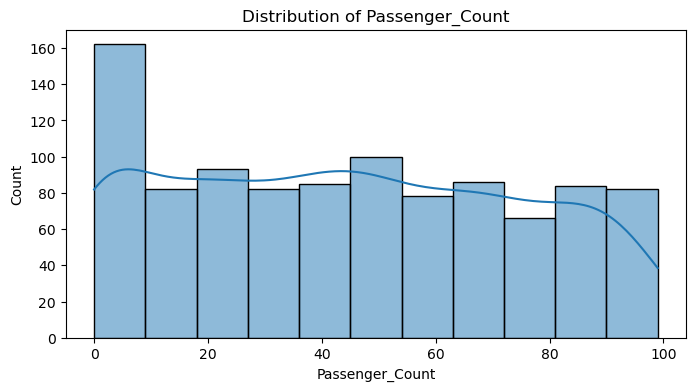

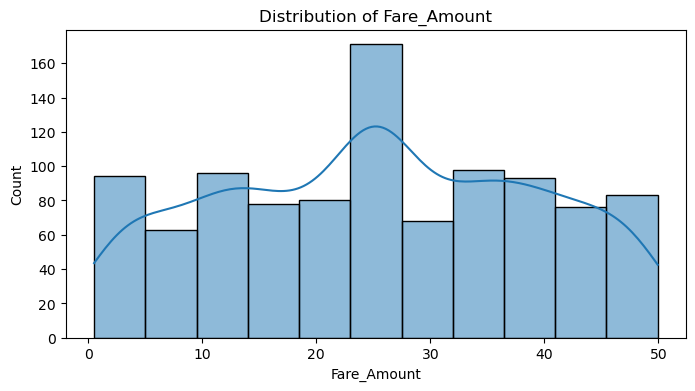

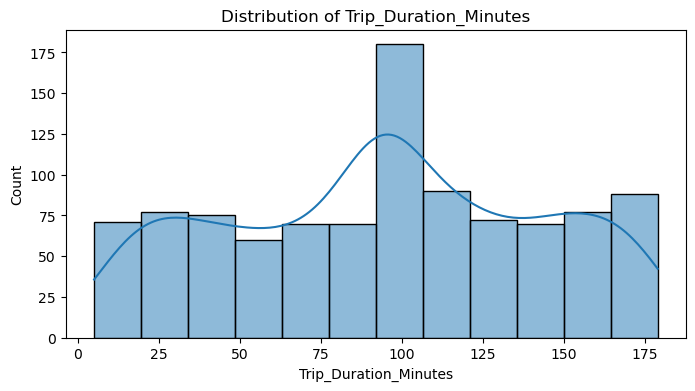

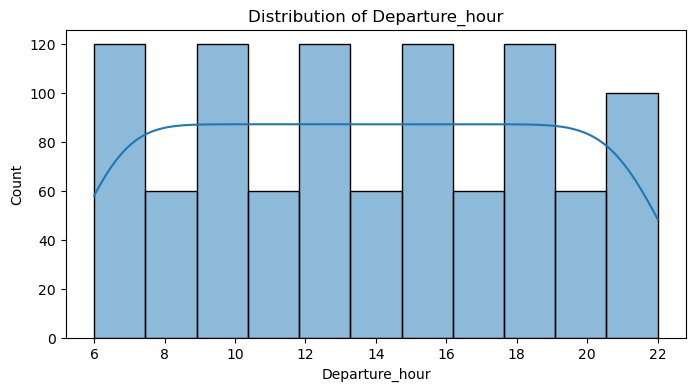

In [22]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### **Insight:**

-  dominated by low values suggesting (solo or low‑occupancy trips dominate) 
- 25–30 units is the most common fare range.
- some higher fares**, but they occur infrequently
- Trip_Duration** → centered around a consistent duration suggests trip durations are **fairly consistent
- The distribution has a clear central mass around **100 minutes**. 
- Departures follow a timetable‑like structure which suggests scheduled or periodic services** 


### BIVARIATE ANALYSIS

In [23]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Departure_hour', 'Trip_Month',
       'Trip_Day'],
      dtype='object')

In [24]:
# Categorization of trip departure hours

def categorize_time(Departure_hour):
    if Departure_hour < 12:
        return 'Morning'
    elif Departure_hour < 17:
        return 'Afternoon'
    elif Departure_hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Departure_Period'] = df['Departure_hour'].apply(categorize_time)

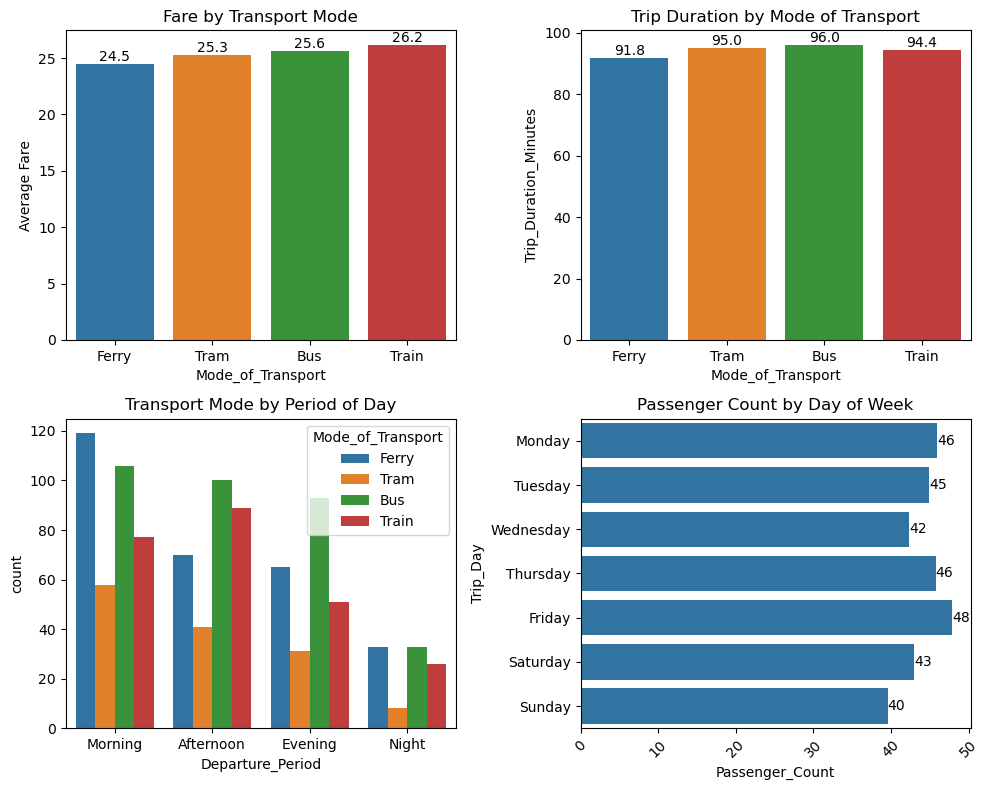

In [25]:
# Categorical vs Numerical

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax = ax.flatten()

# 1. Fare by Transport Mode
sns.barplot(data=df, x='Mode_of_Transport', y='Fare_Amount', hue ='Mode_of_Transport', errorbar=None, ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.1f')
ax[0].set_title("Fare by Transport Mode")
ax[0].set_ylabel("Average Fare")

# 2. Trip Duration by Transport Mode
sns.barplot(data=df, x='Mode_of_Transport', y='Trip_Duration_Minutes', hue ='Mode_of_Transport', errorbar=None, ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f')
ax[1].set_title("Trip Duration by Mode of Transport")

# 3. Transport Mode by Departure Period
sns.countplot(data=df, x='Departure_Period', hue='Mode_of_Transport',
              order=['Morning','Afternoon','Evening','Night'], ax=ax[2])
ax[2].set_title("Transport Mode by Period of Day")

# 4. Passenger Count by Day of Week
sns.barplot(data=df, y='Trip_Day', x='Passenger_Count', errorbar=None,
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
            ax=ax[3])
for container in ax[3].containers:
    ax[3].bar_label(container, fmt='%.0f')
ax[3].set_title("Passenger Count by Day of Week")
ax[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### **Insight:**
- Fares are consistent across modes  
- Trip durations are nearly identical  
- Bus is the most widely used mode across the day  
- Weekly demand is stable with minor fluctuations  

This paints a picture of a **balanced, predictable transport network** with no extreme variations in cost, duration, or daily usage.

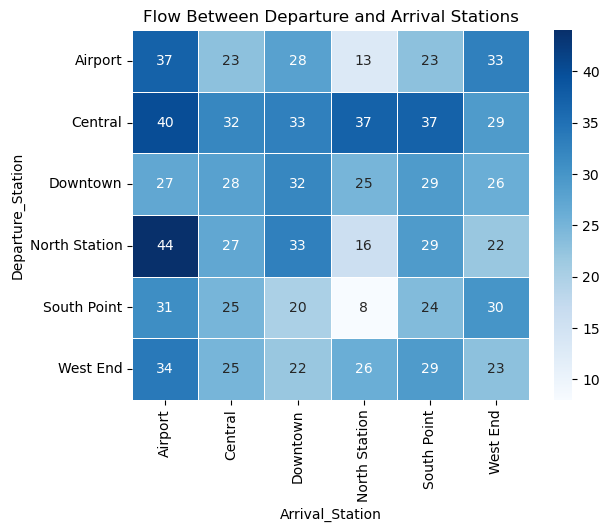

In [26]:
pivot = df.pivot_table(
    index='Departure_Station',
    columns='Arrival_Station',
    values='Trip_ID',      # ← THIS is the feature being counted
    aggfunc='count'
)

sns.heatmap(
    pivot,
    cmap='Blues',
    annot=True,        # adds the numbers
    fmt='.0f',         # no decimals
    linewidths=0.5,    # optional: adds grid lines
    linecolor='white'  # optional: grid line color
)
plt.title("Flow Between Departure and Arrival Stations")
plt.show()

### ** Insight**
The heatmap clearly highlights the busiest station‑to‑station routes, showing where passenger demand is most concentrated within the network.

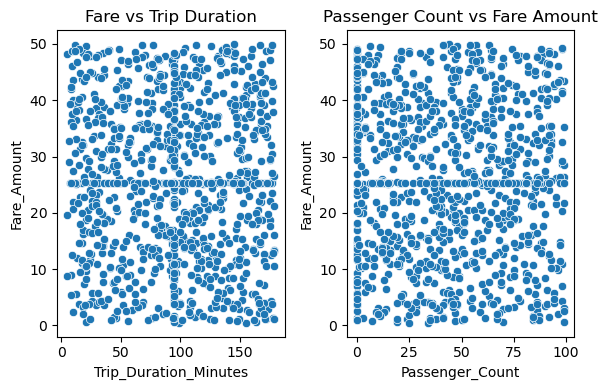

In [27]:
# Numerical vs Numerical


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,4))
ax = ax.flatten()

sns.scatterplot(data=df, x='Trip_Duration_Minutes', y='Fare_Amount', ax=ax[0])
ax[0].set_title("Fare vs Trip Duration")

sns.scatterplot(data=df, x='Passenger_Count', y='Fare_Amount', ax=ax[1])
ax[1].set_title("Passenger Count vs Fare Amount")

plt.tight_layout()
plt.show()

### **Insight** 
The fare system is fixed and does not depend on trip duration or passenger load.

In [28]:
df.to_excel("metromove_cleaned.xlsx", index=False)